# Notebook Overview

This notebook was originally designed for **multi-node experiments**. For users who do not have a multi-node environment or want quick visualization, we provide a **single-machine, multi-process** version.

The core logic is identical to the multi-node implementation, except for process launching.

---

## Communication

Thanks to our custom communication framework:

- Multi-process workers communicate over **TCP loopback (127.0.0.1)**  
- The same networking stack is used as in the multi-node version  

This makes the notebook a faithful stand-in for real distributed runs.

---

## Multi-Node Version

For multi-node experiments, use the scripts in:

```text
examples/multi_node
```

# 1. Basic parameters

In [100]:
import typing
import logging

logging.basicConfig(level=logging.INFO)

import ray
import networkx as nx
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import matplotlib.axes as maxes
import matplotlib.patches as mpatches

N_STATE = 20
N_ITER = 100
ITERS = np.arange(N_ITER)

ALPHA = 0.3
EXP_NAME = "random"

# 2. Define the graph topology

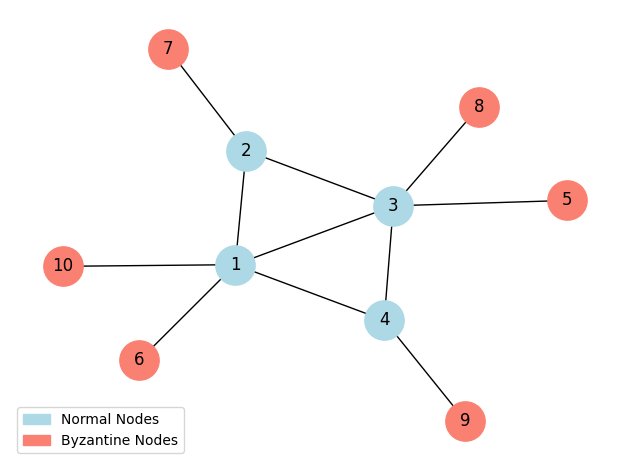

In [101]:
NORMAL_NODES = ["1", "2", "3", "4"]
NORMAL_EDGES = [
    ("1", "2"),
    ("2", "3"),
    ("3", "4"),
    ("4", "1"),
    ("1", "3"),
]
BYZANTINE_NODES = ["5", "6", "7", "8", "9", "10"]
BYZANTINE_EDGES = [("1", "6"), ("2", "7"), ("3", "5"), ("3", "8"), ("4", "9"), ("1", "10")]

NODES = NORMAL_NODES + BYZANTINE_NODES
EDGES = NORMAL_EDGES + BYZANTINE_EDGES

N_NORMAL = len(NORMAL_NODES)
N_BYZANTINE = len(BYZANTINE_NODES)
N_NODES = N_NORMAL + N_BYZANTINE

plt.rcdefaults()

fig, ax = plt.subplots()

G = nx.Graph()
G.add_nodes_from(NODES)
G.add_edges_from(EDGES)

pos = nx.spring_layout(G, seed=13, k=0.8)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=NORMAL_NODES,
    node_color="lightblue",
    node_size=800,
    ax=ax,
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=BYZANTINE_NODES,
    node_color="salmon",
    node_size=800,
    ax=ax,
)

nx.draw_networkx_edges(G, pos, ax=ax)
nx.draw_networkx_labels(G, pos, ax=ax)

blue_patch = mpatches.Patch(color="lightblue", label="Normal Nodes")
red_patch = mpatches.Patch(color="salmon", label="Byzantine Nodes")

ax.legend(handles=[blue_patch, red_patch], loc="lower left")
ax.axis("off")
plt.tight_layout()

fig.savefig("network_topology.pdf", bbox_inches="tight", format="pdf")

from conops import Graph, bootstrap

graph = Graph(NODES, EDGES)

# 3. Attacker model

In [102]:
@ray.remote(num_cpus=1)
def byzantine_node(name: str, n_state: int, alpha: float, n_iter: int) -> None:
    from numpy.random import seed, uniform
    from conops import NodeHandle

    nh = NodeHandle(name, transport="tcp")

    seed(int(name))  # Ensure reproducibility for each node

    for _ in range(n_iter - 1):
        attack_value = uniform(-100, 100, n_state)
        _ = nh.laplacian(attack_value)

# 4. Standard consensus
## (1) Run the algorithm

In [103]:
@ray.remote(num_cpus=1)
def baseline_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> npt.NDArray[np.float64]:
    lower_bound = -100.0
    upper_bound = 100.0

    from numpy import zeros
    from numpy.random import uniform, seed
    from conops import NodeHandle

    nh = NodeHandle(name, transport="tcp")

    x = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    x[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        x[k + 1] = x[k] - nh.laplacian(x[k]) * alpha

    return x


ray.init(address="auto")

try:
    bootstrap(graph)

    bl_refs = {i: baseline_node.remote(i, N_STATE, ALPHA, N_ITER) for i in NORMAL_NODES}

    byz_refs = [
        byzantine_node.remote(i, N_STATE, ALPHA, N_ITER) for i in BYZANTINE_NODES
    ]

    bl_data = {i: ray.get(ref) for i, ref in bl_refs.items()}
    ray.wait(byz_refs)

finally:
    ray.shutdown()

2026-03-31 19:31:06,652	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 192.168.1.111:6379...
2026-03-31 19:31:06,682	INFO worker.py:2004 -- Connected to Ray cluster. View the dashboard at 127.0.0.1:8265 
INFO:conops.bootstrap:Graph 'default' running on: 192.168.1.112:45979
INFO:conops.discovery:Registered graph service with name 'default'
INFO:conops.bootstrap:Node '6' joined graph 'default' from 192.168.1.112:44663.
INFO:conops.bootstrap:Node '5' joined graph 'default' from 192.168.1.111:38949.
INFO:conops.bootstrap:Node '2' joined graph 'default' from 192.168.1.110:33209.
INFO:conops.bootstrap:Node '8' joined graph 'default' from 192.168.1.107:45475.
INFO:conops.bootstrap:Node '9' joined graph 'default' from 192.168.1.108:33677.
INFO:conops.bootstrap:Node '10' joined graph 'default' from 192.168.1.109:35821.
INFO:conops.bootstrap:Node '1' joined graph 'default' from 192.168.1.103:41031.
INFO:conops.bootstrap:Node '7' joined graph 'default' from 192.168.1.106:44

## 

## (2) Visualize the Results

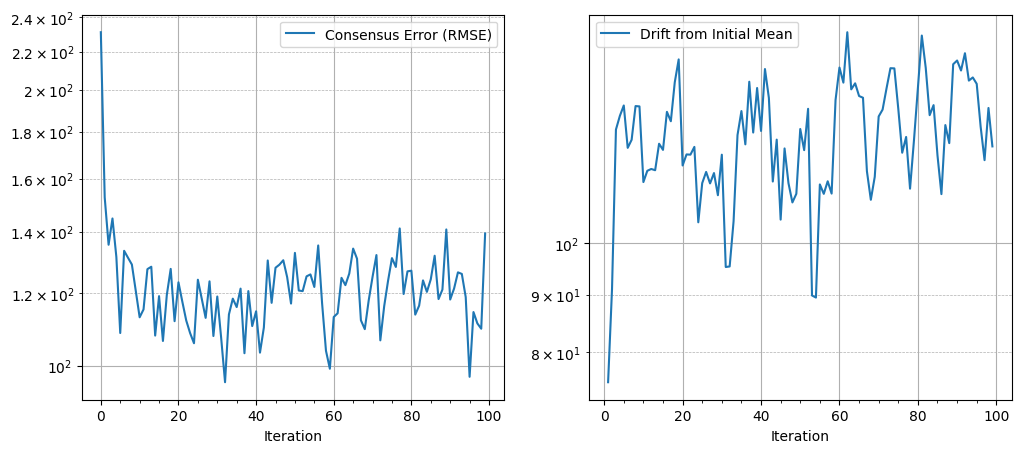

In [ ]:
plt.rcdefaults()

axes: typing.Sequence[maxes.Axes]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bl_states = np.array([bl_data[i] for i in NORMAL_NODES])
avg_states: npt.NDArray[np.float64] = np.average(bl_states, axis=0)
diffs = bl_states - avg_states
bl_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

x0_mean = avg_states[0]
bl_drift = np.linalg.norm(avg_states - x0_mean[None, :], axis=1)

axes[0].semilogy(ITERS, bl_rmse)
axes[0].set_xlabel("Iteration")
axes[0].set_title("RMSE")
axes[0].grid()

axes[1].semilogy(ITERS[1:], bl_drift[1:])
axes[1].set_xlabel("Iteration")
axes[1].set_title("DIA")
axes[1].grid()

# 5. ARepC
## (1) Run the algorithm

In [105]:
@ray.remote(num_cpus=1)
def arepc_node(
    name: str,
    n_state: int,
    alpha: float,
    n_iter: int,
) -> tuple[npt.NDArray[np.float64], dict[str, npt.NDArray[np.float64]]]:
    lower_bound = -100.0
    upper_bound = 100.0

    from numpy import zeros
    from numpy.random import uniform, seed
    from conops import NodeHandle

    nh = NodeHandle(name, transport="tcp")

    from arepc import ARepC

    agent = ARepC(nh, alpha, eta=0.002, normalization="sparsemax")

    x = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    x[0] = uniform(lower_bound, upper_bound, n_state)

    reps = {neighbor: zeros(n_iter - 1) for neighbor in nh.neighbors}

    for k in range(n_iter - 1):
        # Compute new state
        x[k + 1] = agent.weighted_mix(x[k])

        # Record normalized weights history
        r = agent.reputations
        for j in nh.neighbors:
            reps[j][k] = r[j]

    return x, reps


ray.init(address="auto")

try:
    bootstrap(graph)

    arepc_refs = {i: arepc_node.remote(i, N_STATE, ALPHA, N_ITER) for i in NORMAL_NODES}
    byz_refs = [
        byzantine_node.remote(i, N_STATE, ALPHA, N_ITER) for i in BYZANTINE_NODES
    ]

    arepc_data = {i: ray.get(ref) for i, ref in arepc_refs.items()}
    ray.wait(byz_refs)

finally:
    ray.shutdown()

2026-03-31 19:31:11,728	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 192.168.1.111:6379...
2026-03-31 19:31:11,785	INFO worker.py:2004 -- Connected to Ray cluster. View the dashboard at 127.0.0.1:8265 
INFO:conops.bootstrap:Graph 'default' running on: 192.168.1.112:45787
INFO:conops.discovery:Registered graph service with name 'default'
INFO:conops.bootstrap:Node '5' joined graph 'default' from 192.168.1.112:44875.
INFO:conops.bootstrap:Node '6' joined graph 'default' from 192.168.1.111:35837.
INFO:conops.bootstrap:Node '1' joined graph 'default' from 192.168.1.110:38389.
INFO:conops.bootstrap:Node '10' joined graph 'default' from 192.168.1.108:33897.
INFO:conops.bootstrap:Node '9' joined graph 'default' from 192.168.1.107:33789.
INFO:conops.bootstrap:Node '7' joined graph 'default' from 192.168.1.109:36891.
INFO:conops.bootstrap:Node '8' joined graph 'default' from 192.168.1.106:41603.
INFO:conops.bootstrap:Node '3' joined graph 'default' from 192.168.1.104:40

## (2) Reputation

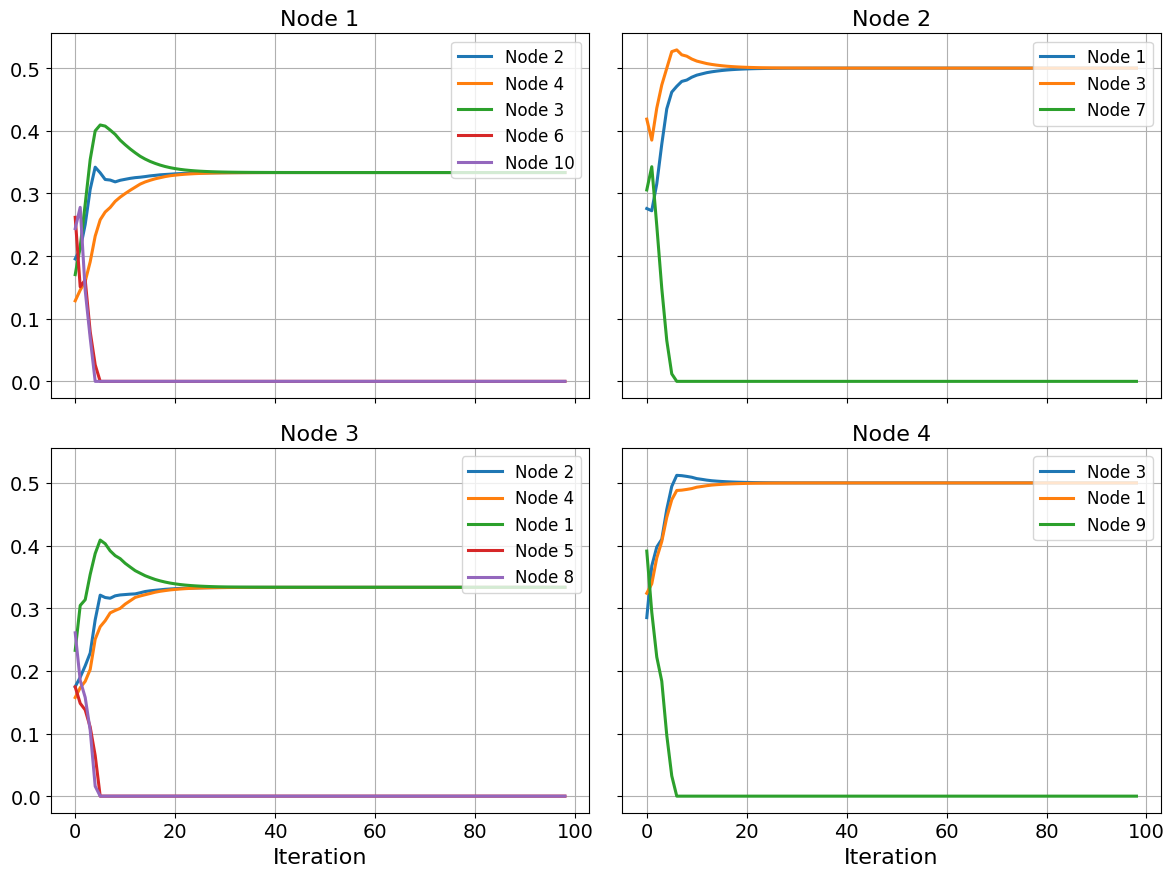

In [113]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "lines.linewidth": 2.2,
    }
)

axes: npt.NDArray
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
axes_flat = axes.flatten()

arepc_reps = {i: arepc_data[i][1] for i in NORMAL_NODES}

for i, ax in zip(NORMAL_NODES, axes_flat):
    ax: maxes.Axes
    reps_for_i = arepc_reps[i]
    for j in reps_for_i:
        ax.plot(reps_for_i[j], label=f"Node {j}")
    ax.set_title(f"Node {i}")
    ax.legend(loc="upper right")
    ax.grid()

    if i in ["3", "4"]:
        ax.set_xlabel("Iteration")

fig.tight_layout()

fig.savefig("arepc_reputations.pdf", bbox_inches="tight", format="pdf")

# 6. RepC
## (1) Run the algorithm

In [107]:
@ray.remote(num_cpus=1)
def repc_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> tuple[npt.NDArray[np.float64], dict[str, npt.NDArray[np.float64]]]:
    lower_bound = -100.0
    upper_bound = 100.0

    from conops import NodeHandle

    nh = NodeHandle(name, transport="tcp")

    from arepc.baselines import RepC

    agent = RepC(nh, alpha, f=1)

    from numpy import zeros
    from numpy.random import uniform, seed

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    reps = {neighbor: zeros(n_iter - 1) for neighbor in nh.neighbors}

    for k in range(n_iter - 1):
        # Compute new state
        states[k + 1] = agent.weighted_mix(states[k])

        # Record normalized weights history
        r = agent.reputations
        for j in nh.neighbors:
            reps[j][k] = r[j]

    return states, reps


ray.init(address="auto")

try:
    bootstrap(graph)

    repc_refs = {i: repc_node.remote(i, N_STATE, ALPHA, N_ITER) for i in NORMAL_NODES}
    byz_refs = [
        byzantine_node.remote(i, N_STATE, ALPHA, N_ITER) for i in BYZANTINE_NODES
    ]

    repc_data = {i: ray.get(ref) for i, ref in repc_refs.items()}
    ray.wait(byz_refs)

finally:
    ray.shutdown()

2026-03-31 19:31:16,377	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 192.168.1.111:6379...
2026-03-31 19:31:16,405	INFO worker.py:2004 -- Connected to Ray cluster. View the dashboard at 127.0.0.1:8265 
INFO:conops.bootstrap:Graph 'default' running on: 192.168.1.112:45259
INFO:conops.discovery:Registered graph service with name 'default'
INFO:conops.bootstrap:Node '5' joined graph 'default' from 192.168.1.112:45139.
INFO:conops.bootstrap:Node '6' joined graph 'default' from 192.168.1.111:33237.
INFO:conops.bootstrap:Node '7' joined graph 'default' from 192.168.1.108:45745.
INFO:conops.bootstrap:Node '8' joined graph 'default' from 192.168.1.107:37475.
INFO:conops.bootstrap:Node '1' joined graph 'default' from 192.168.1.104:40989.
INFO:conops.bootstrap:Node '10' joined graph 'default' from 192.168.1.106:42475.
INFO:conops.bootstrap:Node '2' joined graph 'default' from 192.168.1.105:41257.
INFO:conops.bootstrap:Node '4' joined graph 'default' from 192.168.1.103:43

## (2) Reputation

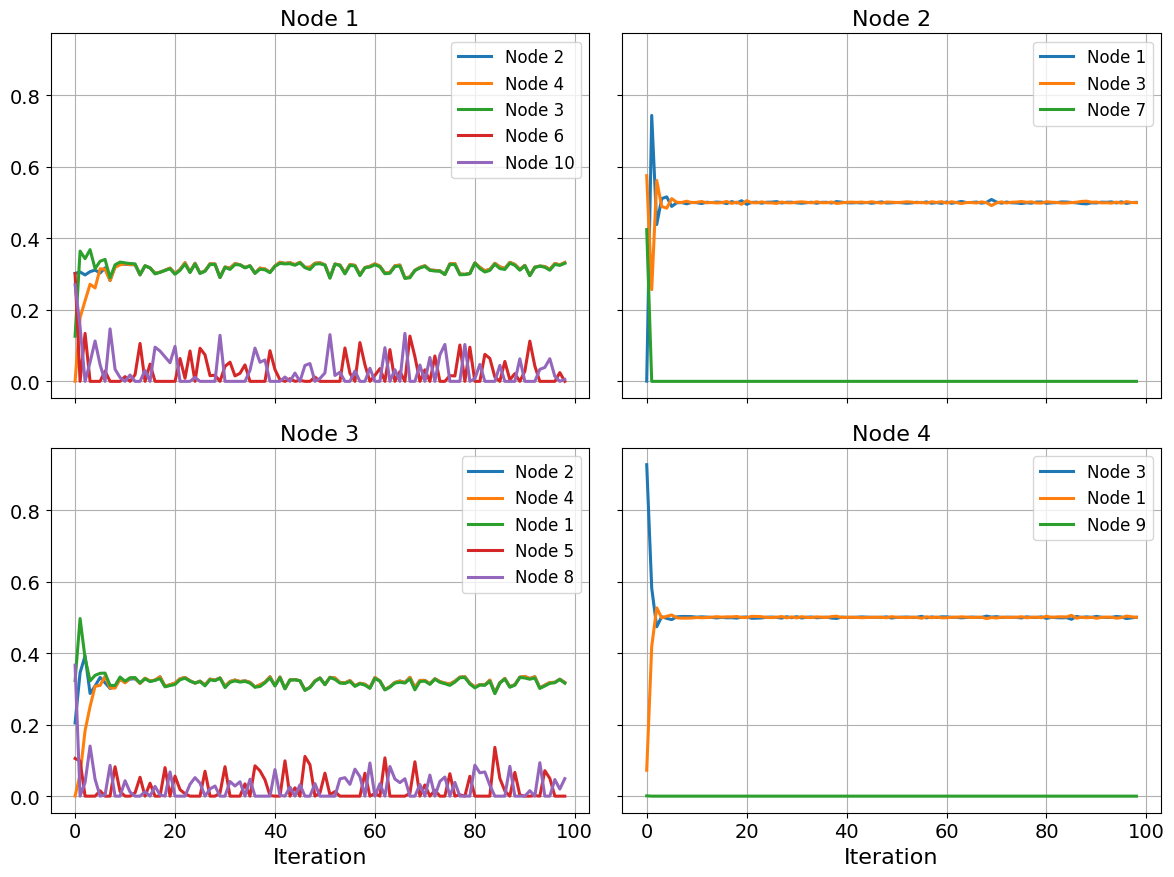

In [114]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "lines.linewidth": 2.2,
    }
)

axes: npt.NDArray
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
axes_flat = axes.flatten()

repc_reps = {i: repc_data[i][1] for i in NORMAL_NODES}

for i, ax in zip(NORMAL_NODES, axes_flat):
    ax: maxes.Axes
    reps_for_i = repc_reps[i]
    for j in reps_for_i:
        ax.plot(reps_for_i[j], label=f"Node {j}")
    ax.set_title(f"Node {i}")
    ax.legend(loc="upper right")
    ax.grid()

    if i in ["3", "4"]:
        ax.set_xlabel("Iteration")

fig.tight_layout()

fig.savefig("repc_reputations.pdf", bbox_inches="tight", format="pdf")

# 7. W-MSR
## (1) Run the algorithm

In [109]:
@ray.remote(num_cpus=1)
def wmsr_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> npt.NDArray[np.float64]:
    lower_bound = -100.0
    upper_bound = 100.0

    from conops import NodeHandle

    nh = NodeHandle(name, transport="tcp")

    from arepc.baselines import WMSR

    agent = WMSR(nh, alpha, f=1)

    from numpy import zeros
    from numpy.random import uniform, seed

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        # Compute new state
        states[k + 1] = agent.weighted_mix(states[k])

    return states


ray.init(address="auto")

try:
    bootstrap(graph)

    wmsr_refs = {i: wmsr_node.remote(i, N_STATE, ALPHA, N_ITER) for i in NORMAL_NODES}
    byz_refs = [
        byzantine_node.remote(i, N_STATE, ALPHA, N_ITER) for i in BYZANTINE_NODES
    ]

    wmsr_data = {i: ray.get(ref) for i, ref in wmsr_refs.items()}
    ray.wait(byz_refs)

finally:
    ray.shutdown()

2026-03-31 19:31:21,294	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 192.168.1.111:6379...
2026-03-31 19:31:21,407	INFO worker.py:2004 -- Connected to Ray cluster. View the dashboard at 127.0.0.1:8265 
INFO:conops.bootstrap:Graph 'default' running on: 192.168.1.112:45361
INFO:conops.discovery:Registered graph service with name 'default'
INFO:conops.bootstrap:Node '5' joined graph 'default' from 192.168.1.112:45217.
INFO:conops.bootstrap:Node '6' joined graph 'default' from 192.168.1.111:38109.
INFO:conops.bootstrap:Node '8' joined graph 'default' from 192.168.1.110:41511.
INFO:conops.bootstrap:Node '9' joined graph 'default' from 192.168.1.107:39661.
INFO:conops.bootstrap:Node '3' joined graph 'default' from 192.168.1.109:43699.
INFO:conops.bootstrap:Node '10' joined graph 'default' from 192.168.1.106:40919.
INFO:conops.bootstrap:Node '4' joined graph 'default' from 192.168.1.105:39049.
INFO:conops.bootstrap:Node '1' joined graph 'default' from 192.168.1.103:45

# 8. WLA
## (1) Run the algorithm

In [ ]:
@ray.remote(num_cpus=1)
def wla_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> npt.NDArray[np.float64]:
    lower_bound = -100.0
    upper_bound = 100.0

    from conops import NodeHandle

    nh = NodeHandle(name, transport="tcp")

    from arepc.baselines import WLA

    agent = WLA(nh, alpha=alpha, eta=0.001)

    from numpy import zeros
    from numpy.random import uniform, seed

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        # Compute new state
        states[k + 1] = agent.weighted_mix(states[k])

    return states


ray.init(address="auto")

try:
    bootstrap(graph)

    wla_refs = {i: wla_node.remote(i, N_STATE, ALPHA, N_ITER) for i in NORMAL_NODES}
    byz_refs = [
        byzantine_node.remote(i, N_STATE, ALPHA, N_ITER) for i in BYZANTINE_NODES
    ]

    wla_data = {i: ray.get(ref) for i, ref in wla_refs.items()}
    ray.wait(byz_refs)

finally:
    ray.shutdown()

# 9. Comparison

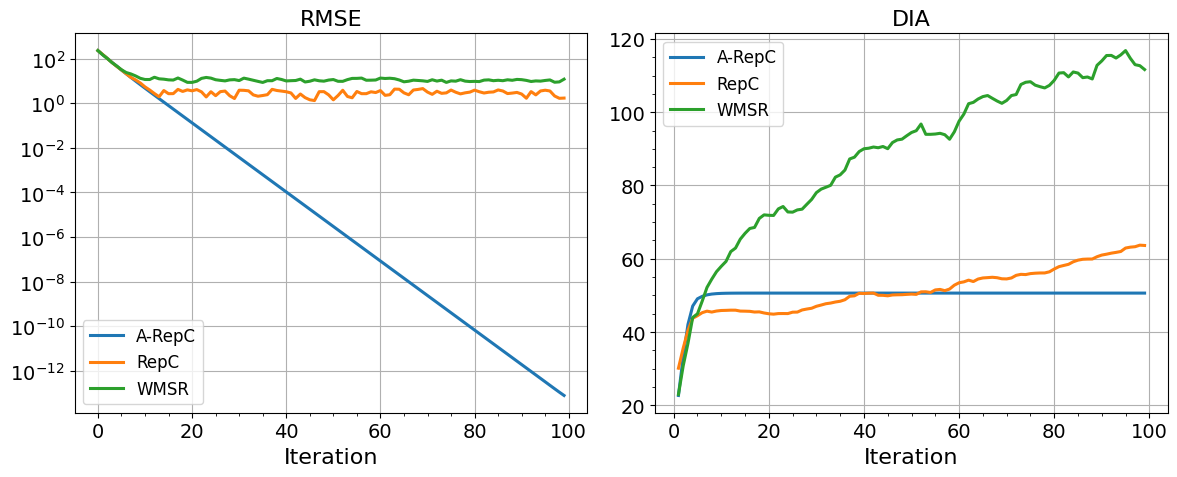

In [ ]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "lines.linewidth": 2.2,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax1: maxes.Axes = axes[0]
ax2: maxes.Axes = axes[1]

arepc_states = np.array([arepc_data[i][0] for i in NORMAL_NODES])
arepc_avg_states: npt.NDArray[np.float64] = np.average(arepc_states, axis=0)
diffs = arepc_states - arepc_avg_states
aprec_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

repc_states = np.array([repc_data[i][0] for i in NORMAL_NODES])
repc_avg_states: npt.NDArray[np.float64] = np.average(repc_states, axis=0)
diffs = repc_states - repc_avg_states
repc_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

wmsr_states = np.array([wmsr_data[i] for i in NORMAL_NODES])
wmsr_avg_states: npt.NDArray[np.float64] = np.average(wmsr_states, axis=0)
diffs = wmsr_states - wmsr_avg_states
wmsr_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

ax1.semilogy(ITERS, aprec_rmse, label="A-RepC")
ax1.semilogy(ITERS, repc_rmse, label="RepC")
ax1.semilogy(ITERS, wmsr_rmse, label="WMSR")
ax1.set_xlabel("Iteration")
ax1.set_title("RMSE")
ax1.legend()
ax1.grid()

fig.tight_layout()

arepc_x0_mean = arepc_avg_states[0]
aprec_drift = np.linalg.norm(arepc_avg_states - arepc_x0_mean[None, :], axis=1)

repc_x0_mean = repc_avg_states[0]
repc_drift = np.linalg.norm(repc_avg_states - repc_x0_mean[None, :], axis=1)

wmsr_x0_mean = wmsr_avg_states[0]
wmsr_drift = np.linalg.norm(wmsr_avg_states - wmsr_x0_mean[None, :], axis=1)

ax2.plot(ITERS[1:], aprec_drift[1:], label="A-RepC")
ax2.plot(ITERS[1:], repc_drift[1:], label="RepC")
ax2.plot(ITERS[1:], wmsr_drift[1:], label="WMSR")
ax2.set_xlabel("Iteration")
ax2.set_title("DIA")
ax2.legend()
ax2.grid()

fig.tight_layout()

fig.savefig("rmse_and_dia.pdf", bbox_inches="tight", format="pdf")